In [1]:
# base and metaprogramming imports
from __future__ import annotations
import os
import shutil
import sys
import itertools as it
import pprint as pp
import warnings

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

# ipynb-specific imports
try:
    import ipynbname
except Exception as e:
    warnings.warn(f'`ipynbname` module import failed with error: {e!r}')
    ipynbname = None
    
if ipynbname is not None:
    _file = ipynbname.path()
else:
    # manually set the full path to the current notebook below if `ipynbname` 
    # import fails
    _file = ''
    
source_dir = os.path.split(_file)[0]
repo_dir = os.path.abspath(os.path.join(source_dir, '..'))
data_dir = os.path.join(repo_dir, 'data')
figure_dir = os.path.join(repo_dir, 'figures')

# add sources directory to path
if source_dir not in sys.path:
    sys.path.append(source_dir)

# local imports
import c_swain_python_utils as csutils

_basename = os.path.basename(_file)
_name = csutils.no_ext_basename(_file)

In [77]:
# plotting defaults
# plotting defaults
# plotting defaults
mpl.font_manager.fontManager.addfont('C:\\Windows\\Fonts\\Linotype - HelveticaLTPro-Black.otf')
mpl.font_manager.fontManager.addfont('C:\\Windows\\Fonts\\Linotype - HelveticaLTPro-Bold.otf')
mpl.font_manager.fontManager.addfont('C:\\Windows\\Fonts\\Linotype - HelveticaLTPro-Roman.otf')
mpl.font_manager.fontManager.addfont('C:\\Windows\\Fonts\\Linotype - HelveticaLTPro-Oblique.otf')
sns.set_style(
    'ticks',
    {'font.sans-serif': ['Helvetica LT Pro', ],
     'mathtext.fontset': ['cm',],
     'axes.linewidth': 2,
     }
)
axes_lw = 1.25
mpl.rcParams['axes.linewidth'] = axes_lw
mpl.rcParams['xtick.major.width'] = axes_lw
mpl.rcParams['xtick.minor.width'] = axes_lw
mpl.rcParams['ytick.major.width'] = axes_lw
mpl.rcParams['ytick.minor.width'] = axes_lw
mpl.rcParams['axes.facecolor'] = 'none'
mpl.rcParams['figure.frameon'] = False
mpl.rcParams['figure.facecolor'] = 'none'
mpl.rcParams['figure.edgecolor'] = 'none'

In [3]:
# setting up logger
csutils.apply_standard_logging_config()
if 'log' in globals():
    log.info('Logger already loaded.')
else:
    log = csutils.get_logger()
    log.info('Logger loaded.')

root ( 197): INFO : Logger loaded.


## Processing Plots for Line Profiles

In [4]:
line_profile_dir_name = 'line_profile'
post_exm_data_name = '306-p1-1_post-exm-line-profile.csv'
pre_exm_data_name = '306-p1-1_pre-exm-line-profile.csv'

gray_val_name = 'Gray_Value'
distance_key = 'Distance_(microns)'
norm_intensity_name = 'norm_intensity'

category_name = 'category'
expanded_cat_name = 'expanded'
unexpanded_cat_name = 'normal'

index_name = 'index'
pixel_index_name = 'pixel_index'

In [5]:
line_profile_dir = os.path.join(data_dir, line_profile_dir_name)

post_exm_data_path = os.path.join(line_profile_dir, post_exm_data_name)
post_df = pd.read_csv(post_exm_data_path)
log.info('Post-ExM DF Info')
post_df.info()

pre_exm_data_path = os.path.join(line_profile_dir, pre_exm_data_name)
pre_df = pd.read_csv(pre_exm_data_path)
log.info('Pre-ExM DF Info')
pre_df.info()

pre_um_per_px = pre_df[distance_key][100] / 100
log.info(f'{pre_um_per_px = }')
post_um_per_px = post_df[distance_key][100] / 100
log.info(f'{post_um_per_px = }')

min_val = post_df[gray_val_name].min()
max_val = post_df[gray_val_name].max()
post_df[norm_intensity_name] = (post_df[gray_val_name]-min_val) / (max_val-min_val)

min_val = pre_df[gray_val_name].min()
max_val = pre_df[gray_val_name].max()
pre_df[norm_intensity_name]  = (pre_df[gray_val_name]-min_val) / (max_val-min_val)

post_df[category_name] = expanded_cat_name
pre_df[category_name] = unexpanded_cat_name

post_df = post_df.reset_index().rename(columns={index_name: pixel_index_name})
pre_df = pre_df.reset_index().rename(columns={index_name: pixel_index_name})

line_profile_df = pd.concat([pre_df, post_df], axis=0).reset_index(drop=True)
line_profile_df[category_name] = line_profile_df[category_name].astype('category')

log.info('Long DF Info:')
line_profile_df.info()
line_profile_df.head(10)

root ( 197): INFO : Post-ExM DF Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Distance_(microns)  320 non-null    float64
 1   Gray_Value          320 non-null    float64
dtypes: float64(2)
memory usage: 5.1 KB
root ( 197): INFO : Pre-ExM DF Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Distance_(microns)  320 non-null    float64
 1   Gray_Value          320 non-null    float64
dtypes: float64(2)
memory usage: 5.1 KB
root ( 197): INFO : pre_um_per_px = np.float64(0.041914999999999994)
root ( 197): INFO : post_um_per_px = np.float64(0.171875)
root ( 197): INFO : Long DF Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (

,pixel_index,Distance_(microns),Gray_Value,norm_intensity,category
0,0,0.0000,1488.407,0.156866,normal
1,1,0.0419,1464.365,0.151340,normal
2,2,0.0838,1422.982,0.141828,normal
3,3,0.1257,1382.455,0.132513,normal
4,4,0.1677,1336.628,0.121979,normal
5,5,0.2096,1292.676,0.111877,normal
6,6,0.2515,1262.964,0.105048,normal
7,7,0.2934,1240.009,0.099772,normal
8,8,0.3353,1220.314,0.095245,normal
9,9,0.3772,1201.941,0.091022,normal


root ( 197): INFO : xlim = (np.float64(-15.950000000000001), np.float64(334.95))


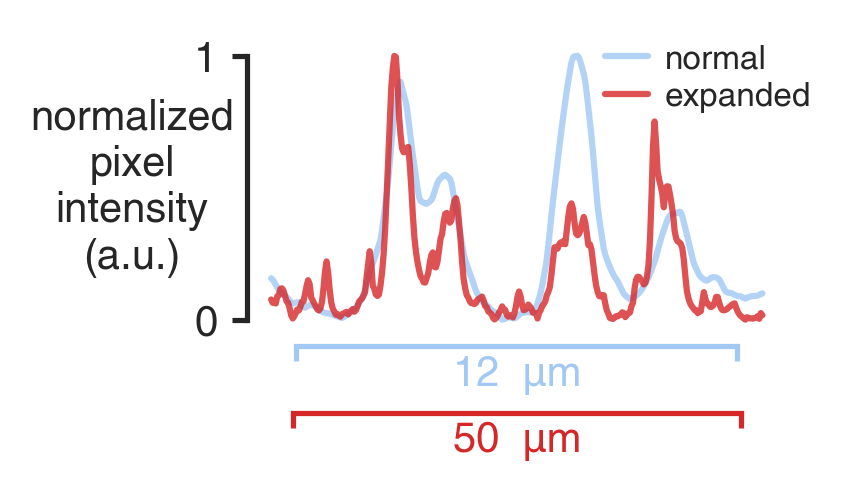

In [6]:
fig = plt.figure(
    figsize=(3, 1.75),
    dpi=300)

palette = sns.color_palette(
    [sns.color_palette('pastel')[0],
     sns.color_palette()[3]])

ax = sns.lineplot(
    data=line_profile_df,
    x=pixel_index_name,
    y=norm_intensity_name,
    hue=category_name,
    hue_order=[unexpanded_cat_name, expanded_cat_name],
    lw=1.5,
    palette=palette,
    alpha=0.8,
    legend=False)
legend = ax.legend(
    ax.lines, 
    [unexpanded_cat_name, expanded_cat_name],
    frameon=False,
    labelspacing=0.2,
    handlelength=1.3,
    handletextpad=0.5,
    fontsize=8,
    loc='upper right',
    bbox_to_anchor=(1.1, 1.05))
sns.despine(
    ax=ax, 
    top=True, 
    right=True, 
    offset={'bottom': 16, 'left': 0})
ax.set_ylabel(
    'normalized\npixel\nintensity\n(a.u.)',
    labelpad=15,
    rotation='horizontal',
    va='center')
ax.set_yticks([0, 1])
ax.spines['left'].set_bounds(0, 1)
ax.set_ylim([-0.1, 1.1])
ax.set_clip_on(False)
xlim = ax.get_xlim()
xlen = xlim[1] - xlim[0]
log.info(f'{xlim = }')
xtick_post_len = 50/post_um_per_px
x_tick_pad_post = ((xlen - xtick_post_len) / 2) + xlim[0]
xtick_post_lim = [
    x_tick_pad_post, 
    x_tick_pad_post + xtick_post_len]
ax.set_xticks(xtick_post_lim)
ax.set_xticklabels([])
ax.set_xlabel('50  \u00b5m', labelpad=-5)
ax.spines['bottom'].set_bounds(*xtick_post_lim)
ax.spines['bottom'].set_color(palette[1])
ax.tick_params(axis='x', colors=palette[1])
ax.xaxis.label.set_color(palette[1])
secax = ax.secondary_xaxis(0)

xtick_pre_len = 12/pre_um_per_px
x_tick_pad_pre = ((xlen - xtick_pre_len) / 2) + xlim[0]
xtick_pre_lim = [
    x_tick_pad_pre, 
    x_tick_pad_pre + xtick_pre_len]

secax.set_xticks(xtick_pre_lim)
secax.set_xticklabels([])
secax.spines['bottom'].set_bounds(*xtick_pre_lim)
secax.set_xlabel('12  \u00b5m', labelpad=-5)
secax.spines['bottom'].set_color(palette[0])
secax.tick_params(axis='x', colors=palette[0])
secax.xaxis.label.set_color(palette[0])
plt.tight_layout()
csutils.save_figures(directory=figure_dir)

## Processing Plot for Nuclei Size Analysis

In [89]:
nuc_size_dname = 'nuc-size-analysis'
normal_1_fname = '306-K_no-exm_006-with-box-1-results_v2.csv'
exm_1_fname = 'K-expand_sd_052-1-RESULTS.csv'
exm_2_fname = 'K-expand_sd_054_with-box-1-RESULTS.csv'

category_key = 'category'
expanded_cat_name = 'expanded'
unexpanded_cat_name = 'normal'

file_key = 'original_file'

area_key = 'Area'
sqrt_area_key = '[Area]^(1/2)'

In [90]:
nuc_size_dir = os.path.join(data_dir, nuc_size_dname)

normal_1_path = os.path.join(nuc_size_dir, normal_1_fname)
exm_1_path = os.path.join(nuc_size_dir, exm_1_fname)
exm_2_path = os.path.join(nuc_size_dir, exm_2_fname)

normal_df = pd.read_csv(normal_1_path)
log.info('-'*70+'\nNormal DF Info:')
normal_df.info()
normal_df[file_key] = normal_1_fname
normal_df[category_key] = unexpanded_cat_name

exm_1_df = pd.read_csv(exm_1_path)
log.info('-'*70+'\nExM 1 DF Info:')
exm_1_df.info()
exm_1_df[file_key] = exm_1_fname

exm_2_df = pd.read_csv(exm_2_path)
log.info('-'*70+'\nExM 1 DF Info:')
exm_2_df.info()
exm_2_df[file_key] = exm_2_fname

exm_df = pd.concat([exm_1_df, exm_2_df]).reset_index(drop=True)
exm_df[category_key] = expanded_cat_name
log.info('-'*70+'\nExM DF Info:')
exm_df.info()

nuc_size_df = pd.concat([exm_df, normal_df]).reset_index(drop=True)
nuc_size_df[category_key] = nuc_size_df[category_key].astype('category')
nuc_size_df[sqrt_area_key] = np.sqrt(nuc_size_df[area_key])
log.info('-'*70+'\nNuc Size DF Info:')
nuc_size_df.info()
nuc_size_df.head(10)

root ( 197): INFO : ----------------------------------------------------------------------
Normal DF Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0             372 non-null    int64  
 1   Area      372 non-null    float64
 2   Circ.     372 non-null    float64
 3   AR        372 non-null    float64
 4   Round     372 non-null    float64
 5   Solidity  372 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 17.6 KB
root ( 197): INFO : ----------------------------------------------------------------------
ExM 1 DF Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0             27 non-null     int64  
 1   Area      27 non-null     float64
 2   Perim.    27 non-null     float64
 3   Circ.     27 non-n

,,Area,Perim.,Circ.,AR,Round,Solidity,original_file,category,[Area]^(1/2)
0,1,1374.697,179.188,0.538,1.262,0.792,0.902,K-expand_sd_052-1-RESULTS.csv,expanded,37.076907
1,2,1163.395,131.813,0.841,1.502,0.666,0.989,K-expand_sd_052-1-RESULTS.csv,expanded,34.108577
2,3,1108.642,137.713,0.735,1.994,0.501,0.984,K-expand_sd_052-1-RESULTS.csv,expanded,33.296276
3,4,1247.122,135.743,0.851,1.384,0.722,0.986,K-expand_sd_052-1-RESULTS.csv,expanded,35.314615
4,5,1480.520,145.119,0.883,1.137,0.880,0.988,K-expand_sd_052-1-RESULTS.csv,expanded,38.477526
5,6,976.176,130.890,0.716,1.571,0.636,0.960,K-expand_sd_052-1-RESULTS.csv,expanded,31.243815
6,7,1649.498,157.702,0.833,1.317,0.759,0.983,K-expand_sd_052-1-RESULTS.csv,expanded,40.614012
7,8,1441.247,144.704,0.865,1.212,0.825,0.987,K-expand_sd_052-1-RESULTS.csv,expanded,37.963759
8,9,598.457,101.944,0.724,1.272,0.786,0.950,K-expand_sd_052-1-RESULTS.csv,expanded,24.463381
9,10,718.293,117.471,0.654,1.351,0.740,0.934,K-expand_sd_052-1-RESULTS.csv,expanded,26.800989


In [91]:
pivot = nuc_size_df.pivot_table(
    columns=category_key,
    values=sqrt_area_key,
    aggfunc='median')
log.info(pivot)

exm_median = pivot[expanded_cat_name].item()
unexm_median = pivot[unexpanded_cat_name].item()
ex_factor = exm_median / unexm_median

count_pivot = nuc_size_df.pivot_table(
    columns=category_key,
    values=sqrt_area_key,
    aggfunc='count')
log.info(count_pivot)
exm_n = count_pivot[expanded_cat_name].item()
unexm_n = count_pivot[unexpanded_cat_name].item()

log.info(f'Expansion Factor: {ex_factor:.1f}')

root ( 197): INFO : category       expanded    normal
[Area]^(1/2)  34.915584  8.718687
root ( 197): INFO : category      expanded  normal
[Area]^(1/2)        55     372
root ( 197): INFO : Expansion Factor: 4.0


C:\Users\CorbanSwain\AppData\Local\Temp\ipykernel_64044\342813030.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = nuc_size_df.pivot_table(
C:\Users\CorbanSwain\AppData\Local\Temp\ipykernel_64044\342813030.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  count_pivot = nuc_size_df.pivot_table(


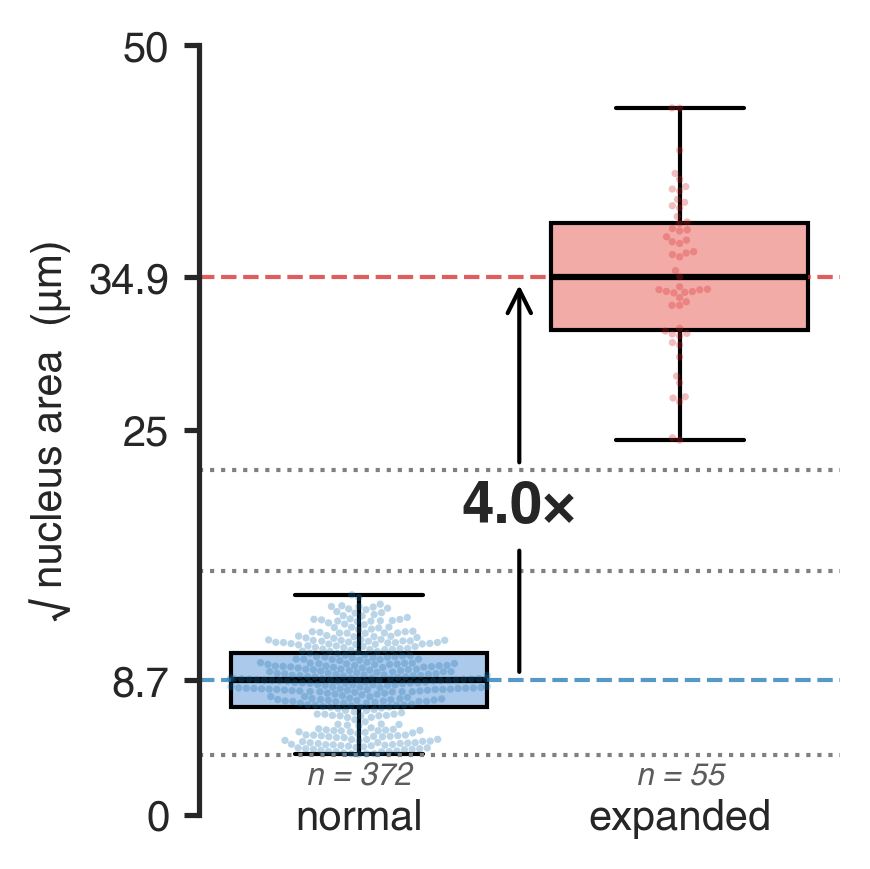

In [96]:
fig = plt.figure(
    figsize=(3, 3),
    dpi=300)

palette_p = sns.color_palette(
    [sns.color_palette('pastel')[0],
     sns.color_palette('pastel')[3]])
palette_n = sns.color_palette(
    [sns.color_palette()[0],
     sns.color_palette()[3]])

ax = sns.boxplot(
    data=nuc_size_df,
    x=category_key,
    y=sqrt_area_key,
    hue=category_key,
    palette=palette_p,
    order=[unexpanded_cat_name, expanded_cat_name],
    hue_order=[unexpanded_cat_name, expanded_cat_name],
    linecolor='k',
    medianprops={'lw': 1.5})
sns.swarmplot(
    data=nuc_size_df,
    x=category_key,
    y=sqrt_area_key,
    hue=category_key,
    size=1.75,
    alpha=0.3,
    ax=ax,
    palette=palette_n,
    color='k',
    order=[unexpanded_cat_name, expanded_cat_name],
    hue_order=[unexpanded_cat_name, expanded_cat_name])
ax.axhline(
    y=unexm_median,
    color=palette_n[0],
    ls='--',
    lw=1,
    alpha=0.75
)
ax.axhline(
    y=exm_median,
    color=palette_n[1],
    ls='--',
    lw=1,
    alpha=0.75
)
sns.despine(right=True, bottom=True, top=True)
ax.set_ylim(0, 50)
ax.spines['bottom'].set_bounds(0, 1)
ax.set_yticks(
    [0, 
     unexm_median,
     25,
     exm_median,
     50])
ax.set_yticklabels(
    ['0',
     f'{unexm_median:.1f}',
     '25',
     f'{exm_median:.1f}',
    '50'])
ax.set_ylabel('\u221A nucleus area  (\u00b5m)')
ax.set_xlabel(None)
ax.annotate(
    f'{ex_factor:.1f}\u00D7',
    xy=(0.5, exm_median),
    xytext=(0.5, 20.0),
    arrowprops=dict(
        arrowstyle='->',
        color='black',
    ),
    annotation_clip=False,
    ha='center',
    va='center',
    size=14,
    weight='bold',
)
ax.annotate(
    f'{ex_factor:.1f}\u00D7',
    xy=(0.5, unexm_median),
    xytext=(0.5, 20.0),
    arrowprops=dict(
        arrowstyle='-',
        color='black',
    ),
    annotation_clip=False,
    ha='center',
    va='center',
    alpha=0,
    size=14,
    weight='bold',
)
ax.text(
    0, 2, 
    f'n = {unexm_n}',
    ha='center',
    va='baseline',
    size=7.5,
    style='oblique',
    alpha=0.75)
ax.text(
    1, 2, 
    f'n = {exm_n}',
    ha='center',
    va='baseline',
    size=7.5,
    style='oblique',
    alpha=0.75)
ax.tick_params(axis='x', length=0, pad=-4)

x = np.array([15, 250,500, 4000])
for v in np.sqrt(x):
    ax.axhline(
        y=v,
        color='gray',
        lw=1,
        ls=':'
    )

plt.tight_layout()
csutils.save_figures(directory=figure_dir)

array([[ 5.56776436, 15.8113883 , 22.36067977, 63.2455532 ]])